In [22]:
import os
import sys

import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("../.."))
from scripts.FMG.fmg_utils import (
    objective_function,
    load_config,
    run_pso,
    modify_results,
    plot_results,
    plot_opt_results
)

In [23]:
# Load data
HS = 20
GnP = "0.5GnP"

config = load_config(f"../../config/FMG/{HS}HSWF_FMG_Config.yaml")

df_exp = pd.read_excel(
    "../../dataset/Master_Curves_Synthetic.xlsx",
    sheet_name=f"{HS}HS",
    usecols=config["samples"][GnP]["usecols"],
    skiprows=config["samples"][GnP]["skiprows"],
    nrows=config["samples"][GnP]["nrows"],
    names=config["samples"][GnP]["column_names"],
    header=None
)

w_freq_exp = df_exp["w_freq"].values
Ep_exp = df_exp["Ep"].values
Epp_exp = df_exp["Epp"].values

# Define optimization hyper-parameters (Clerc & Kennedy)
var_min = config["bounds"]["lower"]
var_max = config["bounds"]["upper"]
n_var = len(var_min)

inertia_coeff = np.linspace(0.9, 0.4, config['pso']['max_it'])
kappa, phi1, phi2 = 1, 2.01, 2.01
phi = phi1 + phi2
chi = 2 * kappa / abs(2 - phi - np.sqrt(phi**2 - 4 * phi))

pso_params = {
    'n_pop': config['pso']['n_pop'],
    'max_it': config['pso']['max_it'],
    'n_runs': config['pso']['n_runs'],
    'var_min': var_min,
    'var_max': var_max,
    'n_var': n_var,
    'inertia_coeff': inertia_coeff,
    'c1': chi * phi1,
    'c2': chi * phi2,
}

# Define the objective function coefficients and the remaining data arguments for optimization
obj_func_coeff = [0.5, 0.5]
data_args = (w_freq_exp, Ep_exp, Epp_exp, obj_func_coeff)

n_run = config['pso']['n_runs']
results = []

for run in range(n_run):
    print(f"\n###### Starting Run {run+1}/{n_run} ######")
    opt_params, best_cost, cost_history = run_pso(objective_function, pso_params, data_args)
    
    # Add the constrained parameter (tau_c2) to the optimized parameters for saving only
    full_opt_params = np.insert(opt_params, 4, opt_params[1] * np.sqrt(opt_params[0] / opt_params[3]))
    
    # Calculate Error (LSE)
    datanorm = obj_func_coeff[0] * np.linalg.norm(np.log(Ep_exp))**2 + obj_func_coeff[1] * np.linalg.norm(np.log(Epp_exp))**2
    lse = np.sqrt(best_cost / datanorm) * 100
    
    results.append(list(full_opt_params) + [best_cost, lse, cost_history.tolist()])

print("\nOptimization Complete.")

# Save Results
final_results_df = pd.DataFrame(
    results,
    columns=['E_c1', 'tau_c1', 'alpha_1', 'E_c2', 'tau_c2', 'alpha_2', 'Best_Cost', 'LSE', 'Cost_History'],
)
final_results_df.to_csv(f"{config['file_path']['results']}/{HS}HS_{GnP}_Opt_Params_Runs.csv", index=False)


###### Starting Run 1/5 ######
Iteration 100: Best Cost = 2.5868e+00
Iteration 200: Best Cost = 2.5293e+00
Iteration 300: Best Cost = 2.5271e+00
Iteration 400: Best Cost = 2.5271e+00
Iteration 500: Best Cost = 2.5271e+00
Iteration 600: Best Cost = 2.5271e+00
Iteration 700: Best Cost = 2.5271e+00
Iteration 800: Best Cost = 2.5271e+00
Iteration 900: Best Cost = 2.5271e+00
Iteration 1000: Best Cost = 2.5271e+00

###### Starting Run 2/5 ######
Iteration 100: Best Cost = 1.3755e+01
Iteration 200: Best Cost = 1.3753e+01
Iteration 300: Best Cost = 1.3753e+01
Iteration 400: Best Cost = 1.2968e+01
Iteration 500: Best Cost = 1.1618e+01
Iteration 600: Best Cost = 1.1618e+01
Iteration 700: Best Cost = 1.1618e+01
Iteration 800: Best Cost = 1.1618e+01
Iteration 900: Best Cost = 1.1618e+01
Iteration 1000: Best Cost = 1.1618e+01

###### Starting Run 3/5 ######
Iteration 100: Best Cost = 2.7018e+00
Iteration 200: Best Cost = 2.5291e+00
Iteration 300: Best Cost = 2.5271e+00
Iteration 400: Best Cost = 2

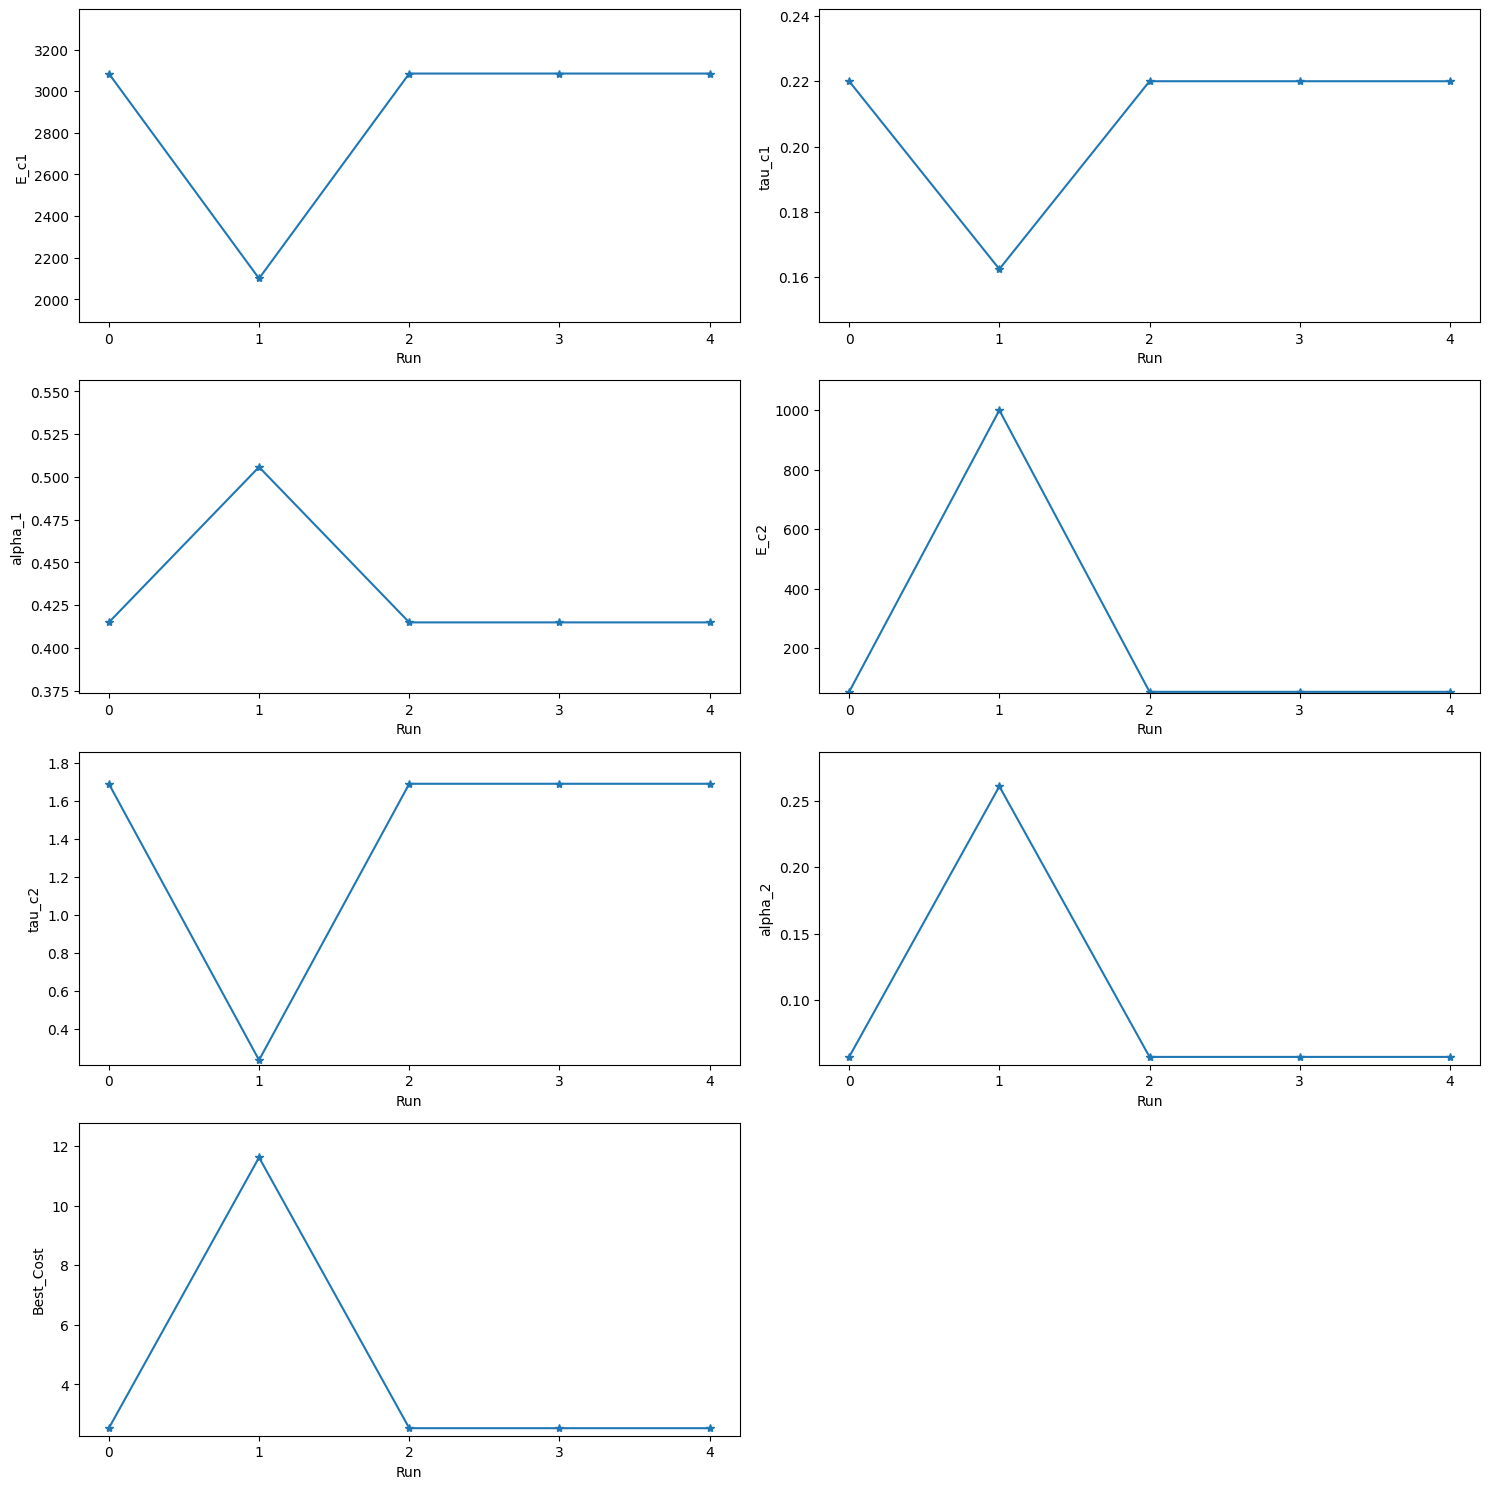

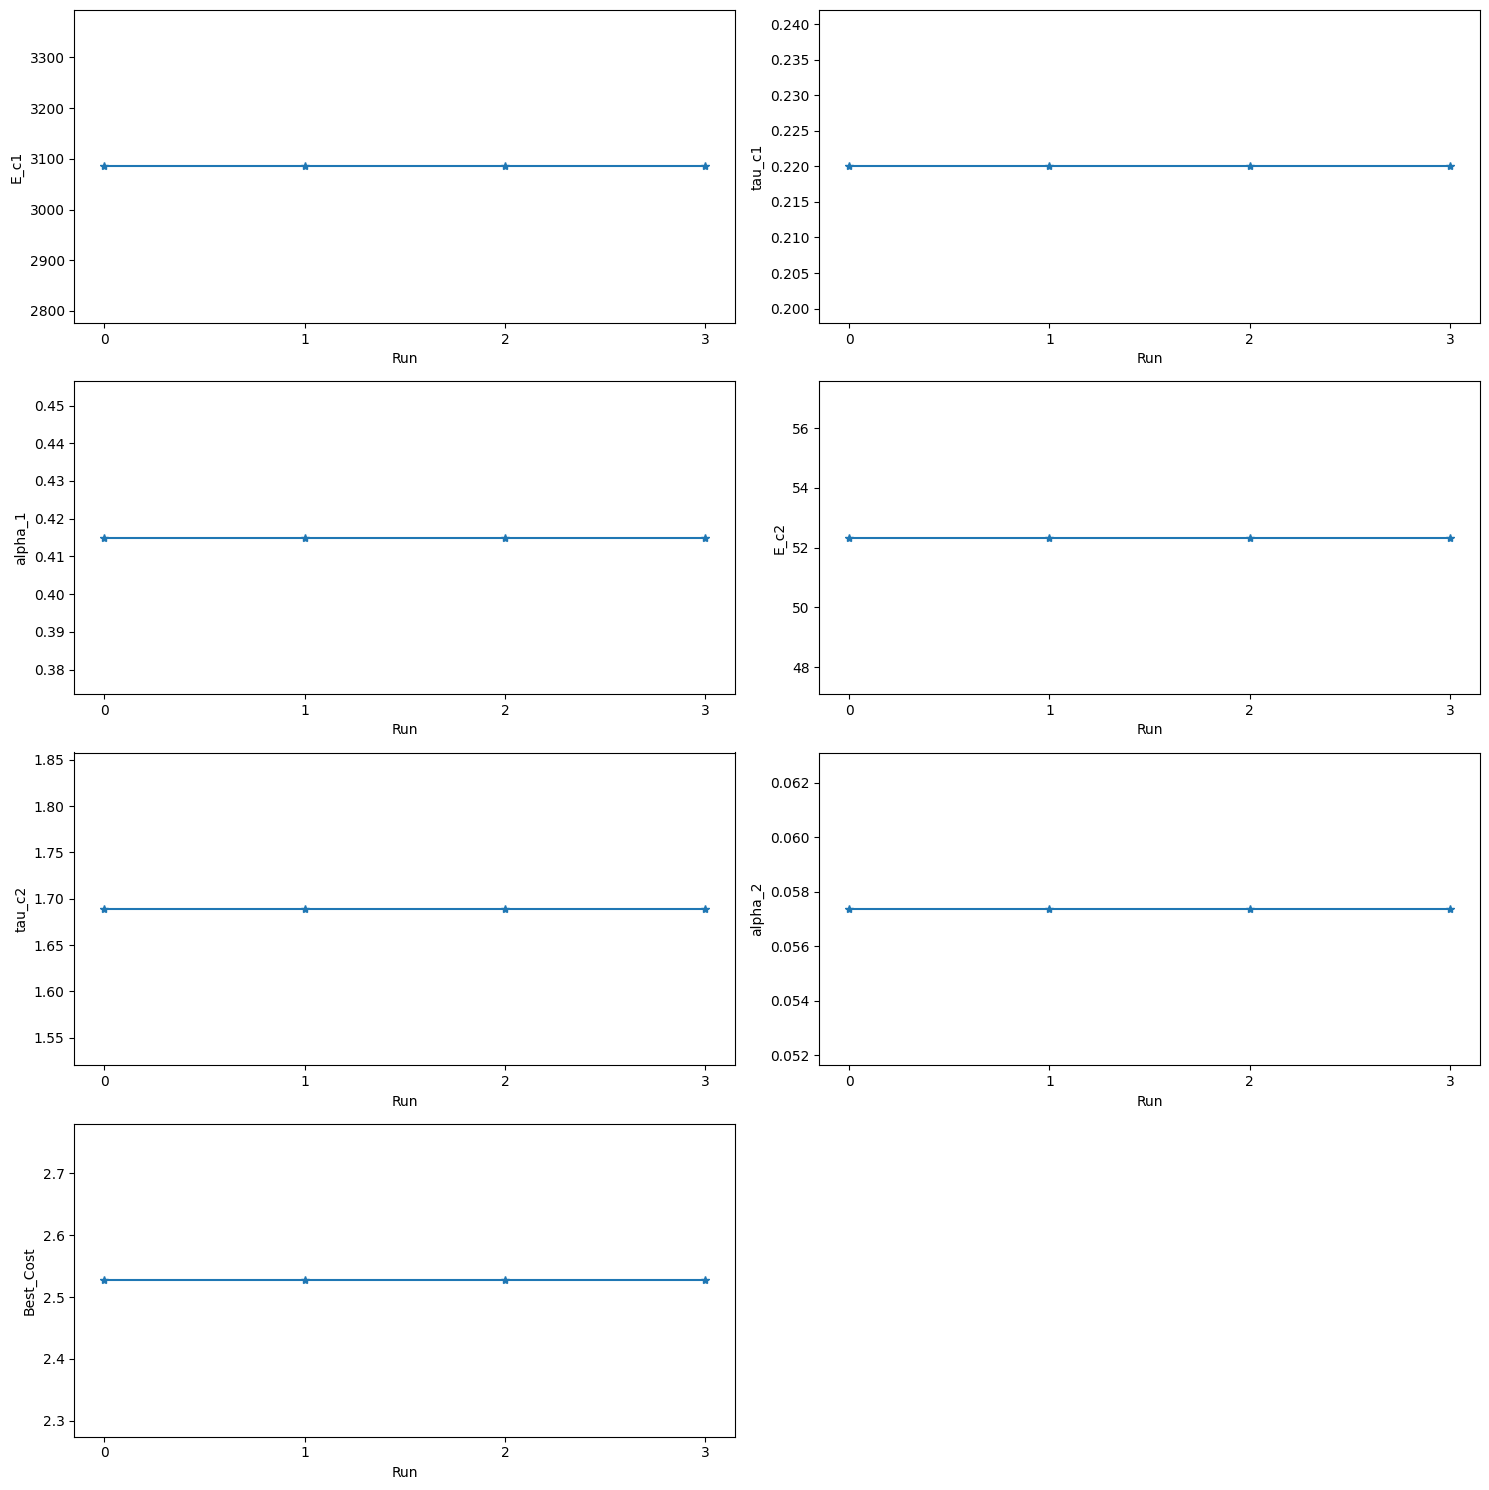

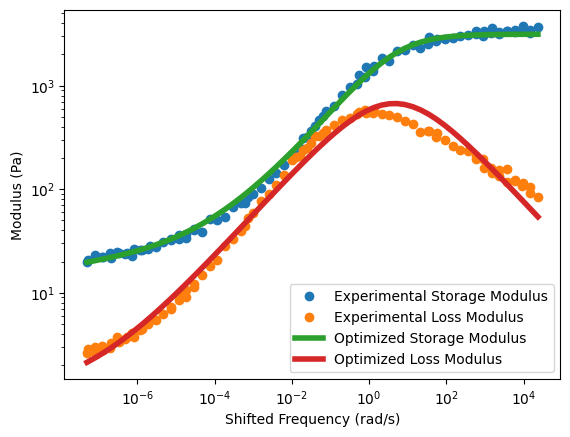

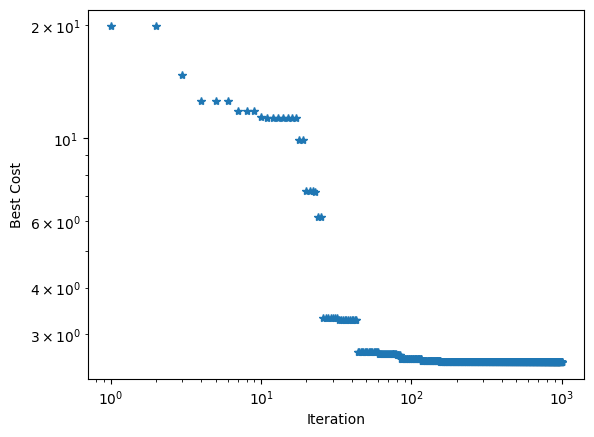

In [24]:
final_results_modified_df = modify_results(final_results_df.copy(), 1.01, config['file_path']['results'], HS, GnP)
plot_results(final_results_df, final_results_modified_df, config['file_path']['results'], HS, GnP)
plot_opt_results(config['file_path']['results'], HS, GnP, w_freq_exp, Ep_exp, Epp_exp, 0)